# Mortality microdata, audited before it is analysed

[MicroSUS.jl](https://github.com/dantebertuzzi/MicroSUS.jl) reads DATASUS microdata — the
Brazilian public health system's record-level files — straight from the ministry's FTP, in
streaming, with per-system typed schemas. This notebook takes one year of death certificates
from the state of Pernambuco, asks what is *missing* from them with
[MissingPatterns.jl](https://github.com/dantebertuzzi/MissingPatterns.jl), and only then does
the statistics.

That order is the point. DATASUS files do not use `missing`: absence is coded, as `9` for
"ignored" or as a blank field, so a table of 68 thousand deaths reads as complete when it is
not. What the audit finds changes what the models at the end are allowed to claim.

> **MicroSUS.jl is a reading tool, not a data source.** It downloads and decodes files published
> by DATASUS / the Brazilian Ministry of Health; their content, accuracy and completeness are the
> publishing agency's responsibility. DATASUS also republishes retroactively, so the same query
> on a different date can return different numbers — the figures below are from one run.

**On Colab, pick the Julia runtime first:** *Runtime ▸ Change runtime type ▸ Julia*.

**One network caveat:** DATASUS publishes over FTP (`ftp://ftp.datasus.gov.br`) and has no HTTPS
mirror, so the download cell needs a runtime that can open an FTP connection. If it fails with a
connection error, that is what happened — the rest of the notebook still reads, since the outputs
committed here come from a real run.

In [ ]:
using Pkg
Pkg.add(["MicroSUS", "MissingPatterns", "DataFrames", "StatsBase",
         "HypothesisTests", "GLM", "StatsModels", "Plots"])

In [ ]:
using MicroSUS, MissingPatterns, DataFrames
using StatsBase, HypothesisTests, GLM, StatsModels
using Dates, Statistics, Plots

## One year of death certificates

`fetch_datasus` downloads, decodes and concatenates in one call. `processar = false` keeps the
raw DATASUS codes, which is what the audit needs to see — the standardisation step would resolve
some of the absences before we had a chance to count them.

The file is about 6 MB compressed and expands several times over; the reader streams it, so
memory stays flat regardless.

In [1]:
raw = fetch_datasus(:SIM_DO; uf = "PE", anos = 2023, processar = false)
size(raw)

┌ Info: cache
└   arquivo = "DOPE2023.dbc"


(68527, 89)

## A table that looks complete

These are the fields the death certificate asks the informant for: sex, race/colour, marital
status, schooling, occupation, whether a doctor attended the deceased, whether there was an
autopsy. Nothing here is `missing`.

In [2]:
campos = [:SEXO, :RACACOR, :ESTCIV, :ESC, :OCUP, :ASSISTMED, :NECROPSIA]

missingsummary(raw[:, campos])

 column     type            missing        %  distribution
 SEXO       InlineStrin…          0    0.00%                      
 RACACOR    InlineStrin…          0    0.00%                      
 ESTCIV     InlineStrin…          0    0.00%                      
 ESC        InlineStrin…          0    0.00%                      
 OCUP       InlineStrin…          0    0.00%                      
 ASSISTMED  InlineStrin…          0    0.00%                      
 NECROPSIA  InlineStrin…          0    0.00%                      
 0 missing of 479689 cells (0.00%) across 7 columns ┊ bins of 3427 rows


## What absence actually looks like

It is all there, coded. `9` is "ignored" across most SIM fields, `0` is "ignored" for `SEXO`, and
a field the informant skipped comes through as an empty string. `isna` counts those as holes
without rewriting the table, one predicate per column — a blanket predicate would be wrong here,
since `9` is a code in `ESC` and a perfectly good first digit of an occupation code.

Note the `ismissing` test first, and `||` short-circuiting: `missing == "9"` is `missing`, not
`false`, and would throw in a boolean context.

In [3]:
ausente = (
    SEXO      = x -> ismissing(x) || x in ("", "0", "9"),
    RACACOR   = x -> ismissing(x) || x in ("", "9"),
    ESTCIV    = x -> ismissing(x) || x in ("", "9"),
    ESC       = x -> ismissing(x) || x in ("", "9"),
    OCUP      = x -> ismissing(x) || x == "",          # 9999xx are real CBO codes, not sentinels
    ASSISTMED = x -> ismissing(x) || x in ("", "9"),
    NECROPSIA = x -> ismissing(x) || x in ("", "9"),
)

missingsummary(raw[:, campos]; isna = ausente)

 column     type            missing        %  distribution
 ASSISTMED  InlineStrin…      19952   29.12%  ▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▂
 NECROPSIA  InlineStrin…      15460   22.56%  ▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
 OCUP       InlineStrin…       8067   11.77%  ▁▂▂▁▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▂
 ESC        InlineStrin…       7819   11.41%  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
 ESTCIV     InlineStrin…       3772    5.50%  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
 RACACOR    InlineStrin…        786    1.15%  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
 SEXO       InlineStrin…         27    0.04%  ▁▁▁▁ ▁  ▁▁▁▁ ▁▁▁▁  ▁
 55883 missing of 479689 cells (11.65%) across 7 columns ┊ bins of 3427 rows


Roughly a tenth of the cells in that block are absent, and the two fields about the circumstances
of death — was a doctor present, was there an autopsy — are absent in a quarter to a third of
certificates.

### The same answer, from the other direction

`process_sim` replaces codes with readable labels, and an unmapped code becomes `missing`. So the
standardised frame should agree with the `isna` audit, field by field. It does, exactly — which
is worth checking rather than assuming, because it is the kind of thing that silently stops being
true when a layout changes.

In [4]:
df = process_sim(raw)

DataFrame(
    campo       = campos,
    isna_bruto  = [count(ausente[c], raw[!, c]) for c in campos],
    missing_std = [count(ismissing, df[!, c]) for c in campos],
)

Row,campo,isna_bruto,missing_std
,Symbol,Int64,Int64
1,SEXO,27,27
2,RACACOR,786,786
3,ESTCIV,3772,3772
4,ESC,7819,7819
5,OCUP,8067,0
6,ASSISTMED,19952,19952
7,NECROPSIA,15460,15460


One row disagrees, and it is the informative one. `OCUP` has no label dictionary in
`process_sim` — occupation codes are a large, version-dependent domain, and a partial dictionary
would erase valid data — so its blanks survive standardisation as empty strings and go on looking
like data. The audit is what finds them.

## Which fields are ignored together

One row per distinct combination of present and absent fields, most frequent first — the
diagnostic R's `mice::md.pattern()` produces.

In [5]:
missingpatterns(raw[:, campos]; isna = ausente, max_patterns = 8)

┏━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃  SEXO   ┃  RACA…  ┃  ESTC…  ┃   ESC   ┃  OCUP   ┃  ASSI…  ┃  NECR…  ┃    n    ┃    %    ┃  freq   ┃
┣━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━┫
┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  39605  ┃  57.8%  ┃ ███████ ┃
┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  █████  ┃  █████  ┃  9777   ┃  14.3%  ┃ ██      ┃
┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  █████  ┃  ░░░░░  ┃  4314   ┃  6.3%   ┃ █       ┃
┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  █████  ┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  2658   ┃  3.9%   ┃         ┃
┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  █████  ┃  ░░░░░  ┃  ░░░░░  ┃  2151   ┃  3.1%   ┃         ┃
┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  █████  ┃  █████  ┃  █████  ┃  2143   ┃  3.1%   ┃         ┃
┃  ░░░░░  ┃  ░░░░░  ┃  █████  ┃  █████  ┃  █████  ┃  ░░░░░  ┃  ░░░░░  ┃  1634   ┃ 

In [6]:
missingcooccurrence(raw[:, campos]; isna = ausente)

┏━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃    ϕ    ┃  SEXO   ┃  RACA…  ┃  ESTC…  ┃   ESC   ┃  OCUP   ┃  ASSI…  ┃  NECR…  ┃
┣━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━┫
┃  SEXO   ┃    —    ┃  0.09   ┃  0.07   ┃  0.05   ┃  0.05   ┃  -0.00  ┃  -0.00  ┃
┃  RACA…  ┃  0.09   ┃    —    ┃  0.16   ┃  0.10   ┃  0.07   ┃  0.05   ┃  0.04   ┃
┃  ESTC…  ┃  0.07   ┃  0.16   ┃    —    ┃  0.48   ┃  0.41   ┃  0.01   ┃  0.01   ┃
┃   ESC   ┃  0.05   ┃  0.10   ┃  0.48   ┃    —    ┃  0.30   ┃  0.04   ┃  0.04   ┃
┃  OCUP   ┃  0.05   ┃  0.07   ┃  0.41   ┃  0.30   ┃    —    ┃  0.13   ┃  0.14   ┃
┃  ASSI…  ┃  -0.00  ┃  0.05   ┃  0.01   ┃  0.04   ┃  0.13   ┃    —    ┃  0.75   ┃
┃  NECR…  ┃  -0.00  ┃  0.04   ┃  0.01   ┃  0.04   ┃  0.14   ┃  0.75   ┃    —    ┃
┗━━━━━━━━━┻━━━━━━━━━┻━━━━━━━━━┻━━━━━━━━━┻━━━━━━━━━┻━━━━━━━━━┻━━━━━━━━━┻━━━━━━━━━┛
 pairwise ϕ of missingness masks ┊ n = 68527 rows


Two blocks, and they are not the same block.

`ASSISTMED` and `NECROPSIA` sit at ϕ = 0.75: they are filled — or not filled — together, which is
what you would expect of two questions answered by the same person from the same knowledge of the
case.

`ESTCIV`, `ESC` and `OCUP` form the second (ϕ 0.30–0.48): marital status, schooling and
occupation go blank together. That is a description of the informant, not of the deceased.
Somebody who did not know the person well enough to state one of the three did not know the other
two either.

## Is the ignoring random?

`by` groups the rows by the values of a column instead of by position. Here: the place where the
death occurred, taken from the standardised frame.

In [7]:
tbl = raw[:, campos]
tbl.LOCAL = df.LOCOCOR

plotmissing(tbl; by = :LOCAL, isna = ausente, layout = :classic)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃                              ┃    0%   ┃    1%   ┃    6%   ┃   11%   ┃   12%   ┃   29%   ┃   23%   ┃    0%   ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━┫
┃             row              ┃  SEXO   ┃  RACA…  ┃  ESTC…  ┃   ESC   ┃  OCUP   ┃  ASSI…  ┃  NECR…  ┃  LOCA…  ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━┫
┃          Domicílio           ┃  ░░░░░  ┃  ·····  ┃  ·····  ┃  ░░░░░  ┃  ░░░░░  ┃  ▓▓▓▓▓  ┃  ▒▒▒▒▒  ┃  ░░░░░  ┃
┃           Hospital           ┃  ·····  ┃  ·····  ┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  ▒▒▒▒▒  ┃  ▒▒▒▒▒  ┃  ░░░░░  ┃
┃Outro estabelecimento de saúde┃  ░░░░░  ┃  ·····  ┃  ·····  ┃  ░░░░░  ┃  ░░░░░  ┃  ▒▒▒▒▒  ┃  ▒▒▒▒▒  ┃  ░░░░░  ┃
┃            Outros            ┃  ·····  ┃  ·····  ┃  ░░░░░  ┃  ░░░░░  ┃  ░░░░░  ┃  ▒▒▒▒▒  ┃  ░░

Read the ramp: `·` is up to 5% missing, `░` up to 15%, `▒` up to 30%, `▓` up to 50%, `█` above
that.

It is not random. Medical assistance is ignored markedly more often for deaths at home than for
deaths in hospital — where the answer is in the chart, somebody writes it down. The `∅` row is
the 26 certificates with no place of death recorded at all (its `LOCAL` cell is black by
construction, since that is the field that put them there), and every other field in that row is
worse filled than in any named group: a certificate filled in badly tends to be filled in badly
throughout.

That is the finding that matters for what follows. Missingness correlated with the circumstances
of death is missingness correlated with cause of death, and complete-case analysis of these
fields is not analysis of a random subsample.

## What complete-case analysis costs

In [8]:
missingrows(raw[:, campos]; isna = ausente)

 missing/row   rows        %  distribution
 0            39605   57.79%  ██████████████████████████████
 1            10586   15.45%  ████████
 2            11588   16.91%  █████████
 3             5388    7.86%  ████
 4              897    1.31%  █
 5              410    0.60%  █
 6               52    0.08%  █
 7                1    0.00%  █
 39605 complete rows (57.79%) ┊ 28922 with ≥1 missing (42.21%) ┊ 8 distinct counts across 7 columns


In [9]:
missingdrop(raw[:, campos]; isna = ausente)

 drop       cols  complete        %  distribution
 —             7     39605   57.79%  █████████████████  ◀ most complete-case cells
 ASSISTMED     6     43919   64.09%  ███████████████████
 NECROPSIA     5     54532   79.58%  ████████████████████████
 OCUP          4     59372   86.64%  ██████████████████████████
 ESC           3     64271   93.79%  ████████████████████████████
 ESTCIV        2     67728   98.83%  ██████████████████████████████
 RACACOR       1     68500   99.96%  ██████████████████████████████
 39605 of 68527 rows complete as given (57.79%) ┊ dropping 0 columns leaves 39605 complete across 7 columns (57.79%)


Fifty-eight per cent of certificates are complete across those seven fields. `missingdrop` prices
the alternative — trading a field for records — and flags the step that maximises the surviving
complete-case block; here it flags dropping nothing, so there is no cheap trade to make. Whether
to spend the other 42% is a modelling decision, and now it is a decision rather than an accident.

## The statistics

From here on, the standardised frame. `eh_agressao` is MicroSUS's CID-10 helper for deaths by
aggression — X85–Y09 plus Y87.1, the subset that maps to what Brazilian public security
statistics call CVLI. Deaths of undetermined intent (Y10–Y34) are deliberately *not* in it.

In [10]:
df.agressao = eh_agressao.(df.CAUSABAS)

(total = nrow(df), agressao = sum(df.agressao))

(total = 68527, agressao = 3689)

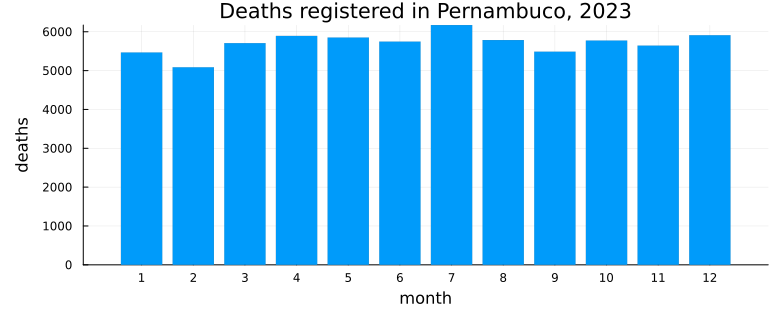

In [11]:
meses = sort(collect(countmap(month.(df.DTOBITO))))

bar(first.(meses), last.(meses);
    legend = false, linewidth = 0, xticks = 1:12,
    xlabel = "month", ylabel = "deaths",
    title = "Deaths registered in Pernambuco, 2023",
    size = (780, 320), left_margin = 6Plots.mm, bottom_margin = 6Plots.mm)

### Age at death

Two distributions, and they barely overlap.

In [12]:
ag  = collect(skipmissing(df.IDADE_ANOS[df.agressao]))
out = collect(skipmissing(df.IDADE_ANOS[.!df.agressao]))

DataFrame(
    grupo = ["aggression", "all other causes"],
    n     = [length(ag), length(out)],
    q25   = [quantile(ag, 0.25), quantile(out, 0.25)],
    mediana = [median(ag), median(out)],
    q75   = [quantile(ag, 0.75), quantile(out, 0.75)],
)

Row,grupo,n,q25,mediana,q75
,String,Int64,Float64,Float64,Float64
1,aggression,3608,23.0,29.0,38.0
2,all other causes,64729,57.0,71.0,82.0


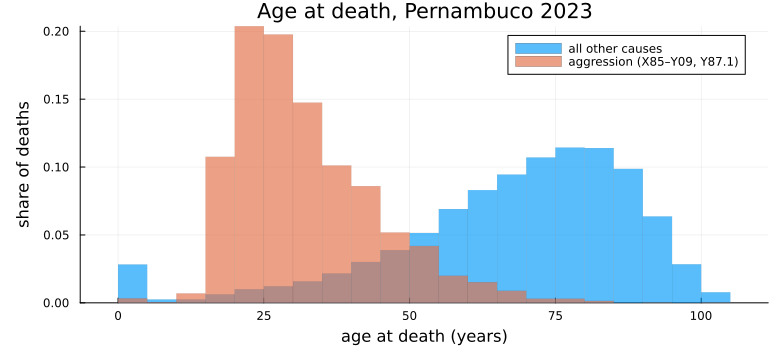

In [13]:
histogram(out; bins = 0:5:105, normalize = :probability, label = "all other causes",
          linewidth = 0, alpha = 0.65)
histogram!(ag; bins = 0:5:105, normalize = :probability, label = "aggression (X85–Y09, Y87.1)",
           linewidth = 0, alpha = 0.65)
plot!(; xlabel = "age at death (years)", ylabel = "share of deaths",
      title = "Age at death, Pernambuco 2023",
      size = (780, 360), left_margin = 6Plots.mm, bottom_margin = 6Plots.mm)

A median of 29 against 71. The test is a formality at this sample size, but state it anyway —
the distributions are skewed and bounded, so rank-based rather than a t-test.

In [14]:
MannWhitneyUTest(ag, out)

Approximate Mann-Whitney U test
-------------------------------
Population details:
    parameter of interest:   not computed (over MAX_PAIRWISE_ESTIMATES)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           <1e-99

Details:
    number of observations in each group: [3608, 64729]
    Mann-Whitney-U statistic:             2.02893e7
    rank sums:                            [2.68e7, 2.30821e9]
    adjustment for ties:                  8.6743e10
    normal approximation (μ, σ):          (-9.64818e7, 1.15309e6)


### Sex and aggression

In [15]:
sub = dropmissing(df[:, [:SEXO, :agressao]])
tab = [count(r -> r.SEXO == s && r.agressao == a, eachrow(sub))
       for s in ["Masculino", "Feminino"], a in [false, true]]

DataFrame(sexo = ["Masculino", "Feminino"], outras = tab[:, 1], agressao = tab[:, 2])

Row,sexo,outras,agressao
,String,Int64,Int64
1,Masculino,33724,3393
2,Feminino,31093,290


In [16]:
ChisqTest(tab)

Pearson's Chi-square Test
-------------------------
Population details:
    parameter of interest:   Multinomial Probabilities
    value under h_0:         [0.51272, 0.433513, 0.0291336, 0.0246329]
    point estimate:          [0.492321, 0.453912, 0.0495328, 0.00423358]
    95% confidence interval: [(0.4876, 0.4971), (0.4492, 0.4587), (0.0475, 0.05164), (0.003657, 0.0049)]

Test summary:
    outcome with 95% confidence: reject h_0
    one-sided p-value:           <1e-99

Details:
    Sample size:        68500
    statistic:          2256.97
    degrees of freedom: 1
    residuals:          [-7.45624, 8.10885, 31.2798, -34.0175]
    std. residuals:     [-47.5075, 47.5075, 47.5075, -47.5075]


### A model, and what it is not

A logistic regression of *is this death an aggression death*, on age, sex and race/colour. The
reference level for race is set to `Branca` explicitly: left alone, the contrast would be against
`Amarela`, a category with 153 deaths in the whole file, and every other coefficient would be
estimated against that noise.

In [17]:
base = dropmissing(df[:, [:agressao, :IDADE_ANOS, :SEXO, :RACACOR]])

modelo = glm(@formula(agressao ~ IDADE_ANOS + SEXO + RACACOR), base, Binomial(), LogitLink();
             contrasts = Dict(:RACACOR => DummyCoding(base = "Branca")))

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

agressao ~ 1 + IDADE_ANOS + SEXO + RACACOR

Coefficients:
────────────────────────────────────────────────────────────────────────────────────
                        Coef.   Std. Error       z  Pr(>|z|)   Lower 95%   Upper 95%
────────────────────────────────────────────────────────────────────────────────────
(Intercept)        -2.15359    0.0791802    -27.20    <1e-99  -2.30878    -1.9984
IDADE_ANOS         -0.0594477  0.000864775  -68.74    <1e-99  -0.0611426  -0.0577528
SEXO: Masculino     2.2125     0.0663203     33.36    <1e-99   2.08252     2.34249
RACACOR: Amarela   -1.09564    1.03939       -1.05    0.2918  -3.13281     0.941541
RACACOR: Indígena  -0.716898   0.502482      -1.43    0.1537  -1.70174     0.267948
RACACOR: Parda      0.671542   0.0

**What this model does not say.** Every row is a death, so the controls are people who died of
something else — the odds ratios compare the *composition* of aggression deaths against the
composition of all other deaths. They are not risks of being killed, and they cannot be, because
nothing here carries a population denominator. Read as composition: among deaths, being male and
being young are strongly associated with the death being an aggression, and the `Parda` and
`Preta` coefficients say the same of race/colour. To turn any of that into a rate you need IBGE
population by age, sex, race and municipality, and a rate is a different notebook.

### The cost of one more variable

Schooling is the obvious next covariate. It is also the fourth-emptiest field in the audit, and
adding it drops every certificate where it was ignored.

In [18]:
com_esc = dropmissing(df[:, [:agressao, :IDADE_ANOS, :SEXO, :RACACOR, :ESC]])

(sem_esc = nrow(base), com_esc = nrow(com_esc), custo = nrow(base) - nrow(com_esc))

(sem_esc = 67570, com_esc = 60230, custo = 7340)

Seven thousand certificates, and by the grouped heatmap above they are not seven thousand random
certificates: schooling is ignored together with marital status and occupation, and ignored more
where the death happened away from a hospital. A complete-case model with schooling in it is
fitted on a sample that excludes, disproportionately, exactly the deaths this analysis is about.

That is not an argument against fitting it. It is an argument for saying so.

## Where to go next

- [MicroSUS.jl documentation](https://dantebertuzzi.github.io/MicroSUS.jl/) (in Portuguese) — every
  system, the FTP layout, custom schemas, and `fontes()` for the full source list
- [MissingPatterns.jl](https://dantebertuzzi.github.io/MissingPatterns.jl/stable) — every entry
  point and keyword, including the whole `isna` story this notebook leans on
- [How to cite](https://github.com/dantebertuzzi/MicroSUS.jl#how-to-cite) — the software, the
  DATASUS files, and the extraction date that makes the numbers reproducible